# MLflow Tracking: Zero-Shot BLIP Baseline

This notebook logs the Day 2 zero-shot BLIP baseline evaluation (BLEU, METEOR, ROUGE-L) into MLflow for experiment tracking.

In [1]:
import mlflow
import pandas as pd

mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("flickr8k-image-captioning")

2026/07/16 12:38:52 INFO mlflow.tracking.fluent: Experiment with name 'flickr8k-image-captioning' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/1', creation_time=1784187532126, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1784187532126, lifecycle_stage='active', name='flickr8k-image-captioning', tags={}, trace_location=None, workspace='default'>

In [2]:
summary_df = pd.read_csv("../data/processed/baseline_evaluation_summary.csv")
summary_df

,Metric,Average Score
0,BLEU,0.1968
1,METEOR,0.3950
2,ROUGE-L,0.5383


In [3]:
with mlflow.start_run(run_name="zero_shot_blip_baseline"):
    
    # Parameters log karein
    mlflow.log_param("model", "Salesforce/blip-image-captioning-base")
    mlflow.log_param("fine_tuned", False)
    mlflow.log_param("validation_size", 200)
    mlflow.log_param("dataset", "Flickr8k")
    
    # Metrics log karein
    for _, row in summary_df.iterrows():
        mlflow.log_metric(row['Metric'], row['Average Score'])
    
    # Result files bhi attach kar dein (artifacts)
    mlflow.log_artifact("../data/processed/baseline_evaluation_detailed.csv")
    mlflow.log_artifact("../data/processed/baseline_evaluation_summary.csv")
    mlflow.log_artifact("../data/processed/baseline_metric_distributions.png")
    
    print("✅ Baseline run logged to MLflow")

✅ Baseline run logged to MLflow
🏃 View run zero_shot_blip_baseline at: http://localhost:5000/#/experiments/1/runs/81d3484e65224546b6b5cee56a42dd90
🧪 View experiment at: http://localhost:5000/#/experiments/1


Now go to MLflow UI (http://localhost:5000) and check the 'flickr8k-image-captioning' experiment."

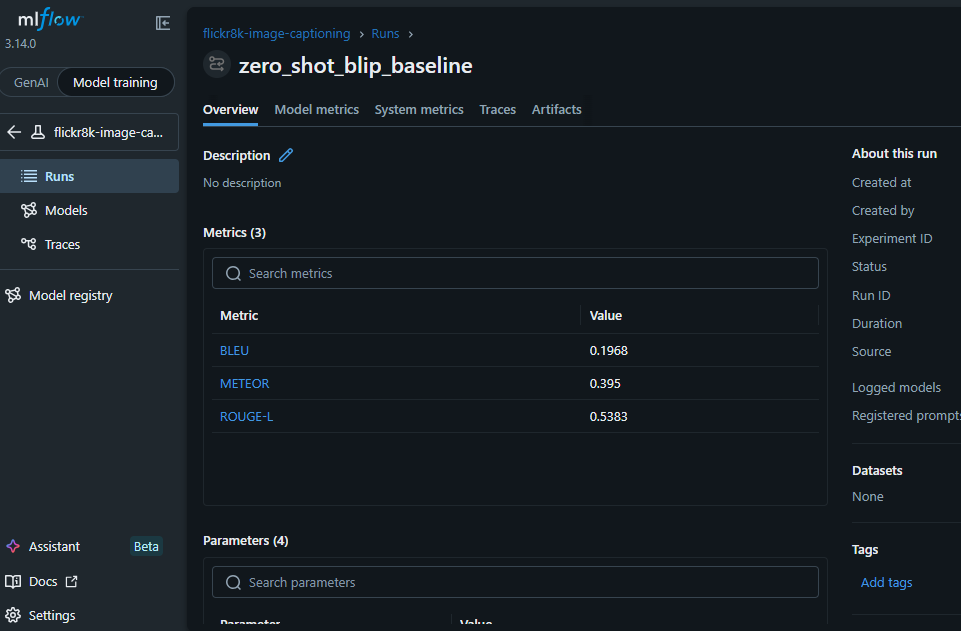

## Light Fine-Tuning Exploration: Freeze Vision Encoder, Train Text Decoder Only

In [5]:
import torch
from transformers import BlipProcessor, BlipForConditionalGeneration

device = "cuda" if torch.cuda.is_available() else "cpu"

processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base").to(device)

# Vision encoder freeze karein (isay train nahi karna)
for param in model.vision_model.parameters():
    param.requires_grad = False

# Text decoder ko trainable rehne dein
for param in model.text_decoder.parameters():
    param.requires_grad = True

# Confirm karein kitne parameters trainable hain
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())

print(f"Trainable parameters: {trainable_params:,}")
print(f"Total parameters: {total_params:,}")
print(f"Trainable %: {100 * trainable_params / total_params:.2f}%")

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

Trainable parameters: 137,881,148
Total parameters: 223,971,644
Trainable %: 61.56%


In [6]:
import pandas as pd
import os

df = pd.read_csv("../data/captions.txt", sep="|")
df.columns = df.columns.str.strip()

# Sirf 50 images ka chhota training subset (light exploration ke liye)
train_subset = df.drop_duplicates(subset=['image_name']).sample(50, random_state=42)
print(f"Training subset size: {len(train_subset)} images")
train_subset.head()

Training subset size: 50 images


,image_name,caption_number,caption_text
20970,3139895886_5a6d495b13.jpg,0,"A black-and-white dog bounds off the ground , ..."
20830,3133825703_359a0c414d.jpg,0,A child staring at Santa .
9640,244910177_7c4ec3f65b.jpg,0,Three woman walk down a city street and one ha...
5305,2127207912_9298824e66.jpg,0,"The two people are standing on a rock , holdin..."
3680,1810651611_35aae644fb.jpg,0,A closeup of a little girl on a swing .


In [7]:
from torch.utils.data import Dataset
from PIL import Image

class FlickrDataset(Dataset):
    def __init__(self, df, image_folder, processor):
        self.df = df.reset_index(drop=True)
        self.image_folder = image_folder
        self.processor = processor

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(os.path.join(self.image_folder, row['image_name'])).convert("RGB")
        caption = str(row['caption_text'])
        encoding = self.processor(images=image, text=caption, padding="max_length", 
                                   truncation=True, max_length=30, return_tensors="pt")
        encoding = {k: v.squeeze() for k, v in encoding.items()}
        return encoding

train_dataset = FlickrDataset(train_subset, "../data/Images", processor)
print(f"Dataset ready with {len(train_dataset)} samples")

Dataset ready with 50 samples


In [8]:
from torch.utils.data import DataLoader
from torch.optim import AdamW

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=5e-5)

model.train()
epoch_losses = []

for batch in train_loader:
    input_ids = batch["input_ids"].to(device)
    pixel_values = batch["pixel_values"].to(device)
    attention_mask = batch["attention_mask"].to(device)
    
    outputs = model(input_ids=input_ids, pixel_values=pixel_values, 
                     attention_mask=attention_mask, labels=input_ids)
    loss = outputs.loss
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    epoch_losses.append(loss.item())

avg_loss = sum(epoch_losses) / len(epoch_losses)
print(f"✅ Light fine-tuning demo complete. Average loss: {avg_loss:.4f}")

✅ Light fine-tuning demo complete. Average loss: 6.3224


In [9]:
with mlflow.start_run(run_name="light_finetune_decoder_only_demo"):
    mlflow.log_param("model", "Salesforce/blip-image-captioning-base")
    mlflow.log_param("fine_tuned", True)
    mlflow.log_param("frozen_component", "vision_encoder")
    mlflow.log_param("trained_component", "text_decoder")
    mlflow.log_param("train_subset_size", 50)
    mlflow.log_param("epochs", 1)
    mlflow.log_param("learning_rate", 5e-5)
    mlflow.log_param("trainable_params", trainable_params)
    
    mlflow.log_metric("avg_training_loss", avg_loss)
    
    print("✅ Light fine-tuning demo run logged to MLflow")

✅ Light fine-tuning demo run logged to MLflow
🏃 View run light_finetune_decoder_only_demo at: http://localhost:5000/#/experiments/1/runs/80736cdbbd5c49fe964d6d9eceb154fa
🧪 View experiment at: http://localhost:5000/#/experiments/1


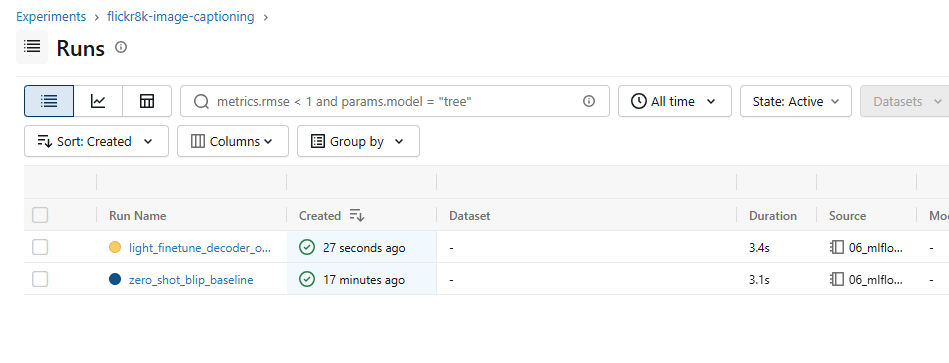

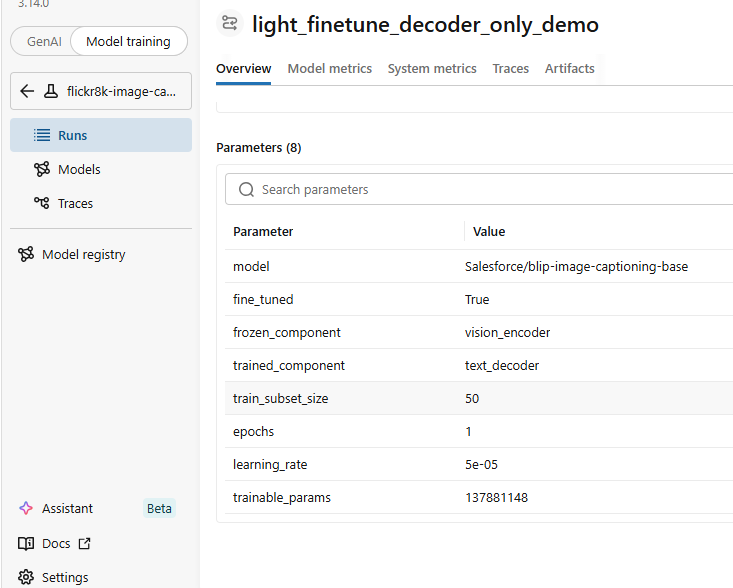